# Energy Forecast Lab: Assignment Ready Colab Notebook

This single Google Colab notebook is an updated assignment-ready version of the electricity demand forecasting project.

It includes the required components:

- Weekly electricity demand modelling.
- Manual SARIMA grid search using p = 0-6, d = 0-2, q = 0-6 and AIC.
- SARIMA forecasting with confidence intervals.
- SARIMA residual diagnostics using histogram and residual ACF.
- SARIMAX with temperature as an exogenous variable.
- Hourly LSTM forecasting model.
- Model comparison and exports.
- LSTM literature review.
- Operational forecast and conditional forecast discussion.
- Written answers to assignment questions.

## 1. Install Required Libraries

Environment Setup: 1. Install Required Libraries
Objective: This cell is used to install the required packages so the notebook can run in Google Colab.

Why: This step is important because it helps prepare Google Colab with all external libraries required for statistical, machine learning, and deep learning forecasting. It also makes the assignment logic clear before the code is executed.

Expected Output: After this cell runs, the environment or project settings should be ready for the next step.

In [ ]:
!pip -q install pmdarima openmeteo-requests requests-cache retry-requests tensorflow joblib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.2/777.2 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.0 MB/s eta 0:00:00


## 2. Import Libraries

Environment Setup: 2. Import Libraries
Objective: This cell is used to import the libraries used for data handling, visualization, statistical models, machine learning, and LSTM modelling.

Why: This step is important because it helps load all Python packages needed for the complete modelling workflow. It also makes the assignment logic clear before the code is executed.

Expected Output: After this cell runs, the environment or project settings should be ready for the next step.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

import openmeteo_requests
import requests_cache
from retry_requests import retry

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

## 3. Project Configuration

Objective: This cell is used to define constants that control the dataset, modelling horizon, seasonal period, and random seed.

Why: This step is important because it helps centralize dataset paths, date ranges, forecast horizons, and reproducibility settings. It also makes the assignment logic clear before the code is executed.

Expected Output: After this cell runs, the environment or project settings should be ready for the next step.

In [ ]:
DATA_URL = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"
DATE_COLUMN = "utc_timestamp"
LOAD_COLUMN = "DE_load_actual_entsoe_transparency"

START_DATE = "2015-01-01"
END_DATE = "2020-10-31"

WEEKLY_FORECAST_HORIZON = 104
SEASONAL_PERIOD = 52
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 4. Load And Clean German Electricity Demand Data

Data Loading and Cleaning: 4. Load And Clean German Electricity Demand Data
Objective: This cell is used to load the German electricity demand dataset and clean it into a time-indexed series.

Why: This step is important because it helps download, filter, clean, and index the German electricity demand dataset. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should confirm that the notebook can continue to the next assignment section.

In [ ]:
def load_electricity_data():
    df = pd.read_csv(DATA_URL)
    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
    df = df[[DATE_COLUMN, LOAD_COLUMN]].copy()
    df.columns = ["Date", "Load"]
    df = df[(df["Date"] >= START_DATE) & (df["Date"] <= END_DATE)]
    df = df.drop_duplicates().dropna().sort_values("Date")
    df = df.set_index("Date")
    return df

hourly_df = load_electricity_data()
print("Hourly data shape:", hourly_df.shape)
hourly_df.head()

Hourly data shape: (50400, 1)


,Load
Date,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


## 5. Weekly And Monthly Resampling

Data Preparation: 5. Weekly And Monthly Resampling
Objective: This cell is used to create daily, weekly, and monthly versions of the load data from the original hourly series.

Why: This step is important because it helps convert hourly demand into daily, weekly, and monthly series for different levels of analysis. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should confirm that the notebook can continue to the next assignment section.

In [ ]:
daily_df = hourly_df.resample("D").mean()
weekly_df = hourly_df.resample("W").mean()
monthly_df = hourly_df.resample("M").mean()

print("Daily shape:", daily_df.shape)
print("Weekly shape:", weekly_df.shape)
print("Monthly shape:", monthly_df.shape)
weekly_df.head()

Daily shape: (2100, 1)
Weekly shape: (301, 1)
Monthly shape: (69, 1)


,Load
Date,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


## 6. Exploratory Visualization

Exploratory Data Analysis: 6. Exploratory Visualization
Objective: This cell is used to visualize the weekly demand trend and distribution to understand the data before modelling.

Why: This step is important because it helps inspect demand distribution and time-based behaviour before modelling. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should include a table or visual diagnostic that supports interpretation.

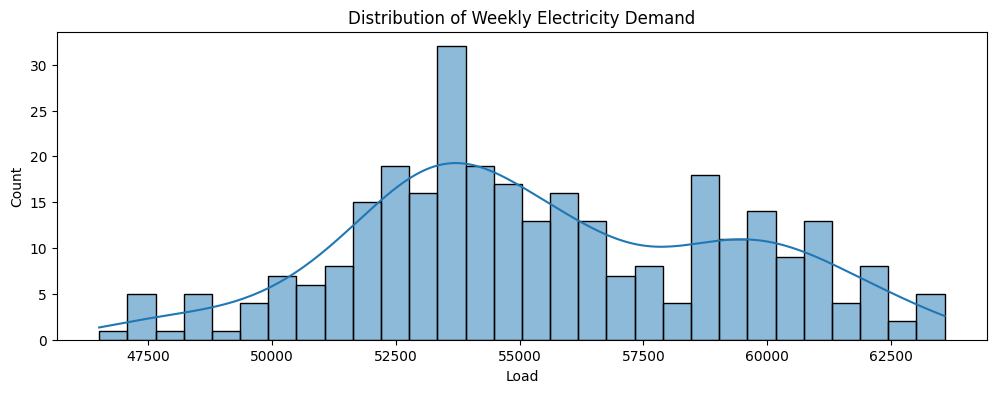

In [ ]:
fig = px.line(weekly_df, x=weekly_df.index, y="Load", title="Weekly German Electricity Demand")
fig.update_layout(xaxis_title="Date", yaxis_title="Electricity Load")
fig.show()

plt.figure(figsize=(12, 4))
sns.histplot(weekly_df["Load"], bins=30, kde=True)
plt.title("Distribution of Weekly Electricity Demand")
plt.xlabel("Load")
plt.show()

## 7. Seasonal Decomposition

Objective: This cell is used to decompose weekly load into trend, seasonal, and residual components.

Why: This step is important because it helps separate the weekly demand series into trend, seasonal, and residual components. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should include a table or visual diagnostic that supports interpretation.

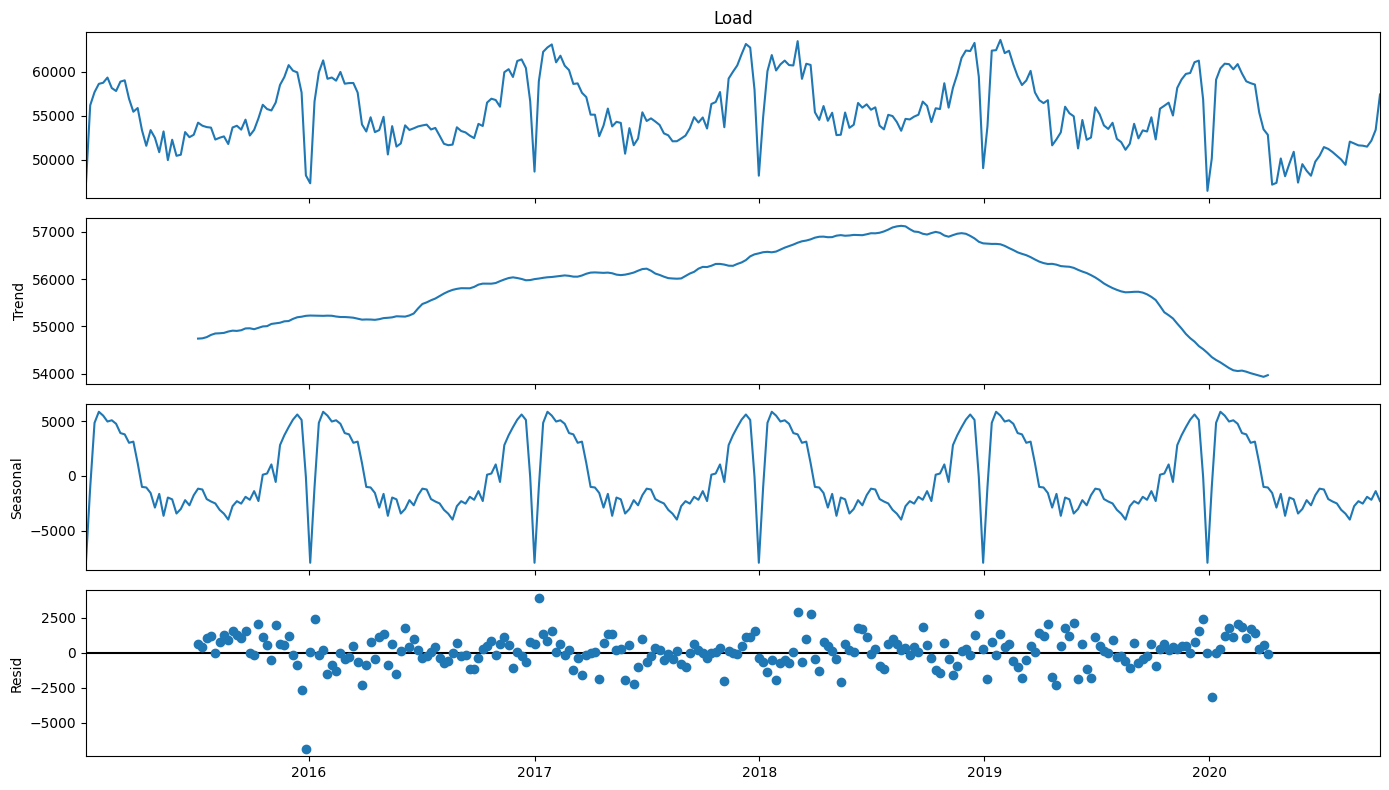

In [ ]:
decomposition = seasonal_decompose(weekly_df["Load"], model="additive", period=SEASONAL_PERIOD)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

## 8. Stationarity And Differencing Justification

Objective: This cell is used to run ADF tests on original and differenced series to justify differencing choices.

Why: This step is important because it helps test whether differencing is required before SARIMA modelling. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should confirm that the notebook can continue to the next assignment section.

In [ ]:
def adf_report(series, title):
    result = adfuller(series.dropna())
    print(title)
    print("=" * len(title))
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

adf_report(weekly_df["Load"], "ADF Test: Original Weekly Load")
adf_report(weekly_df["Load"].diff(), "ADF Test: First Difference")
adf_report(weekly_df["Load"].diff(SEASONAL_PERIOD), "ADF Test: Seasonal Difference")

ADF Test: Original Weekly Load
ADF Statistic : -4.0475
p-value       : 0.0012
Lags Used     : 8
Observations  : 292
Critical Values:
  1%: -3.4529
  5%: -2.8715
  10%: -2.5721
ADF Test: First Difference
ADF Statistic : -7.0693
p-value       : 0.0000
Lags Used     : 7
Observations  : 292
Critical Values:
  1%: -3.4529
  5%: -2.8715
  10%: -2.5721
ADF Test: Seasonal Difference
ADF Statistic : -4.2951
p-value       : 0.0005
Lags Used     : 2
Observations  : 246
Critical Values:
  1%: -3.4572
  5%: -2.8734
  10%: -2.5731


### Differencing Justification

The weekly load series contains strong annual seasonality, so a seasonal period of 52 is appropriate for weekly data. The ADF test is used to check whether the original series is stationary. If the p-value is high, differencing is justified because SARIMA assumes a stable mean over time. First differencing handles trend-like changes, while seasonal differencing handles repeated yearly patterns.

## 9. Weekly Train-Test Split

Objective: This cell is used to split the weekly data chronologically into training and testing periods.

Why: This step is important because it helps create a chronological training and testing split that avoids data leakage. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should confirm that the notebook can continue to the next assignment section.

In [ ]:
train_weekly = weekly_df.iloc[:-WEEKLY_FORECAST_HORIZON]
test_weekly = weekly_df.iloc[-WEEKLY_FORECAST_HORIZON:]

print("Training weeks:", len(train_weekly))
print("Testing weeks:", len(test_weekly))

Training weeks: 197
Testing weeks: 104


## 10. Evaluation And Plotting Helpers

Objective: This cell is used to create reusable evaluation and plotting functions for all forecasting models.

Why: This step is important because it helps define reusable functions for model scoring and forecast visualization. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should confirm that the notebook can continue to the next assignment section.

In [ ]:
def evaluate_forecast(actual, predicted):
    actual = np.asarray(actual).reshape(-1)
    predicted = np.asarray(predicted).reshape(-1)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape


def add_result(rows, model_name, actual, predicted, frequency="Weekly"):
    mae, rmse, mape = evaluate_forecast(actual, predicted)
    rows.append({
        "Frequency": frequency,
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
    })
    return rows


def plot_forecast_with_ci(train, test, prediction, title, confidence=None):
    plt.figure(figsize=(16, 5))
    plt.plot(train.index, train["Load"], label="Training")
    plt.plot(test.index, test["Load"], label="Actual")
    plt.plot(test.index, prediction, label="Forecast")
    if confidence is not None:
        plt.fill_between(test.index, confidence.iloc[:, 0], confidence.iloc[:, 1], alpha=0.25, label="95% Confidence Interval")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Electricity Load")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 11. Required Manual SARIMA Grid Search

The assignment requires a manual loop through p = 0-6, d = 0-2, and q = 0-6 using AIC.

The seasonal part is fixed as `(1, 1, 1, 52)` because the weekly data has annual seasonality. The grid search selects the best non-seasonal `(p, d, q)` order by the lowest AIC.

This cell can take several minutes in Colab.

SARIMA Parameter Selection: 11. Required Manual SARIMA Grid Search
Objective: This cell is used to run the required manual SARIMA grid search over p, d, and q values using AIC.

Why: This step is important because it helps search required SARIMA parameter combinations and select the model with the lowest AIC. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should show the best SARIMA order, seasonal order, AIC value, and top grid-search results.

In [ ]:
p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)
seasonal_order = (1, 1, 1, SEASONAL_PERIOD)

grid_results = []
best_aic = np.inf
best_order = None
best_grid_model = None

for order in itertools.product(p_values, d_values, q_values):
    try:
        model = SARIMAX(
            train_weekly["Load"],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted = model.fit(disp=False, maxiter=75)
        grid_results.append({"order": order, "seasonal_order": seasonal_order, "AIC": fitted.aic})

        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = order
            best_grid_model = fitted

    except Exception as error:
        grid_results.append({"order": order, "seasonal_order": seasonal_order, "AIC": np.nan})

sarima_grid_table = pd.DataFrame(grid_results).sort_values("AIC").reset_index(drop=True)
print("Best SARIMA order:", best_order)
print("Best seasonal order:", seasonal_order)
print("Best AIC:", best_aic)
sarima_grid_table.head(10)

## 12. SARIMA Forecasting With Confidence Intervals

Objective: This cell is used to generate SARIMA forecasts, confidence intervals, and evaluation metrics.

Why: This step is important because it helps forecast weekly electricity demand and represent forecast uncertainty using confidence intervals. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
sarima_results = best_grid_model
sarima_forecast = sarima_results.get_forecast(steps=len(test_weekly))
sarima_predictions = sarima_forecast.predicted_mean
sarima_confidence = sarima_forecast.conf_int()

plot_forecast_with_ci(
    train_weekly,
    test_weekly,
    sarima_predictions,
    "SARIMA Forecast With 95% Confidence Intervals",
    sarima_confidence,
)

model_rows = []
model_rows = add_result(model_rows, "SARIMA", test_weekly["Load"], sarima_predictions)
mae, rmse, mape = evaluate_forecast(test_weekly["Load"], sarima_predictions)
print(f"SARIMA MAE  : {mae:.2f}")
print(f"SARIMA RMSE : {rmse:.2f}")
print(f"SARIMA MAPE : {mape:.2f}%")

## 13. Required SARIMA Residual Diagnostics

Objective: This cell is used to plot SARIMA residuals, their histogram, and residual autocorrelation.

Why: This step is important because it helps evaluate whether SARIMA residuals resemble random noise. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should include a table or visual diagnostic that supports interpretation.

In [ ]:
sarima_residuals = sarima_results.resid.dropna()

plt.figure(figsize=(14, 4))
plt.plot(sarima_residuals)
plt.title("SARIMA Residuals Over Time")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(sarima_residuals, bins=30, kde=True)
plt.title("SARIMA Residual Histogram")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(sarima_residuals, lags=40)
plt.title("SARIMA Residual ACF")
plt.show()

## 14. Temperature Data For SARIMAX

SARIMAX requires an exogenous variable. This project uses Berlin daily mean temperature from Open-Meteo, resampled to weekly frequency.

For the test period, the SARIMAX model uses observed future temperatures. This is a conditional forecast because it assumes future exogenous values are known.

Exogenous Data Preparation: 14. Temperature Data For SARIMAX
Objective: This cell is used to download Berlin temperature data and align it with the weekly electricity series.

Why: This step is important because it helps download and align weekly temperature data for SARIMAX modelling. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
def load_berlin_temperature():
    cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    params = {
        "latitude": 52.52,
        "longitude": 13.41,
        "start_date": "2015-01-01",
        "end_date": "2020-12-31",
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }

    responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
    daily = responses[0].Daily()

    dates = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s"),
        end=pd.to_datetime(daily.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left",
    )

    temperature = pd.DataFrame({
        "Date": dates,
        "Temperature": daily.Variables(0).ValuesAsNumpy(),
    })
    temperature = temperature.set_index("Date").resample("W").mean()
    temperature.index = temperature.index.tz_localize(None)
    return temperature

temperature_weekly = load_berlin_temperature()
weekly_exog = weekly_df.copy()
weekly_exog.index = weekly_exog.index.tz_convert(None) if weekly_exog.index.tz is not None else weekly_exog.index
weekly_exog = weekly_exog.join(temperature_weekly, how="inner")

print(weekly_exog.shape)
weekly_exog.head()

## 15. Required SARIMAX With Temperature Exogenous Variable

Objective: This cell is used to fit and evaluate a SARIMAX model using temperature as an exogenous variable.

Why: This step is important because it helps fit a SARIMAX model using temperature as an external regressor. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
train_exog = weekly_exog.iloc[:-WEEKLY_FORECAST_HORIZON]
test_exog = weekly_exog.iloc[-WEEKLY_FORECAST_HORIZON:]

sarimax_model = SARIMAX(
    train_exog["Load"],
    exog=train_exog[["Temperature"]],
    order=best_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_results = sarimax_model.fit(disp=False, maxiter=75)

sarimax_forecast = sarimax_results.get_forecast(
    steps=len(test_exog),
    exog=test_exog[["Temperature"]],
)
sarimax_predictions = sarimax_forecast.predicted_mean
sarimax_confidence = sarimax_forecast.conf_int()

plot_forecast_with_ci(
    train_exog[["Load"]],
    test_exog[["Load"]],
    sarimax_predictions,
    "SARIMAX Forecast With Temperature Exogenous Variable",
    sarimax_confidence,
)

model_rows = add_result(model_rows, "SARIMAX with Temperature", test_exog["Load"], sarimax_predictions)
mae, rmse, mape = evaluate_forecast(test_exog["Load"], sarimax_predictions)
print(f"SARIMAX MAE  : {mae:.2f}")
print(f"SARIMAX RMSE : {rmse:.2f}")
print(f"SARIMAX MAPE : {mape:.2f}%")

## 16. Extra Weekly Machine Learning Models

Objective: This cell is used to engineer forecasting features and train Random Forest and Gradient Boosting models.

Why: This step is important because it helps train tree-based forecasting models using engineered lag, rolling, calendar, and weather features. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
def create_weekly_features(data):
    ml = data.copy()
    for lag in [1, 2, 3, 4, 52]:
        ml[f"Lag_{lag}"] = ml["Load"].shift(lag)
    ml["Rolling_Mean_4"] = ml["Load"].rolling(4).mean()
    ml["Rolling_STD_4"] = ml["Load"].rolling(4).std()
    ml["Month"] = ml.index.month
    ml["Week"] = ml.index.isocalendar().week.astype(int)
    return ml.dropna()

ml_data = create_weekly_features(weekly_exog)
FEATURES = ["Temperature", "Lag_1", "Lag_2", "Lag_3", "Lag_4", "Lag_52", "Rolling_Mean_4", "Rolling_STD_4", "Month", "Week"]

X = ml_data[FEATURES]
y = ml_data["Load"]
X_train = X.iloc[:-WEEKLY_FORECAST_HORIZON]
X_test = X.iloc[-WEEKLY_FORECAST_HORIZON:]
y_train = y.iloc[:-WEEKLY_FORECAST_HORIZON]
y_test = y.iloc[-WEEKLY_FORECAST_HORIZON:]

rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE)
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)

rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
gb_predictions = gb_model.predict(X_test)

model_rows = add_result(model_rows, "Random Forest", y_test, rf_predictions)
model_rows = add_result(model_rows, "Gradient Boosting", y_test, gb_predictions)

importance = pd.DataFrame({"Feature": FEATURES, "Importance": rf_model.feature_importances_}).sort_values("Importance", ascending=False)
importance

## 17. Hourly LSTM Model Required By Assignment

Objective: This cell is used to scale hourly load data and convert it into input-output sequences for LSTM training.

Why: This step is important because it helps transform hourly load data into supervised learning sequences for LSTM. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
# The assignment requires using hourly data for LSTM.
# This is a univariate sequence model using the previous 168 hours to forecast the next hour.

hourly_lstm_df = hourly_df.asfreq("H").interpolate()
scaler = MinMaxScaler()
scaled_hourly = scaler.fit_transform(hourly_lstm_df[["Load"]])

TIME_STEPS = 168
HOURLY_TEST_HORIZON = 24 * 30

X_seq, y_seq = [], []
for i in range(TIME_STEPS, len(scaled_hourly)):
    X_seq.append(scaled_hourly[i - TIME_STEPS:i])
    y_seq.append(scaled_hourly[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_lstm_train = X_seq[:-HOURLY_TEST_HORIZON]
X_lstm_test = X_seq[-HOURLY_TEST_HORIZON:]
y_lstm_train = y_seq[:-HOURLY_TEST_HORIZON]
y_lstm_test = y_seq[-HOURLY_TEST_HORIZON:]

print("X_lstm_train:", X_lstm_train.shape)
print("X_lstm_test :", X_lstm_test.shape)

## 18. Train Hourly LSTM

Objective: This cell is used to build and train the LSTM neural network with early stopping.

Why: This step is important because it helps train a neural network model for short-term hourly load forecasting. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
lstm_model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

## 19. Evaluate Hourly LSTM

Objective: This cell is used to inverse-transform LSTM predictions and evaluate the hourly forecast accuracy.

Why: This step is important because it helps compare LSTM predictions against actual hourly demand. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should produce model predictions and accuracy metrics for comparison.

In [ ]:
lstm_scaled_predictions = lstm_model.predict(X_lstm_test)
lstm_predictions = scaler.inverse_transform(lstm_scaled_predictions).reshape(-1)
lstm_actual = scaler.inverse_transform(y_lstm_test).reshape(-1)

lstm_index = hourly_lstm_df.index[-HOURLY_TEST_HORIZON:]

mae, rmse, mape = evaluate_forecast(lstm_actual, lstm_predictions)
print(f"Hourly LSTM MAE  : {mae:.2f}")
print(f"Hourly LSTM RMSE : {rmse:.2f}")
print(f"Hourly LSTM MAPE : {mape:.2f}%")

model_rows = add_result(model_rows, "LSTM", lstm_actual, lstm_predictions, frequency="Hourly")

plt.figure(figsize=(16, 5))
plt.plot(lstm_index, lstm_actual, label="Actual")
plt.plot(lstm_index, lstm_predictions, label="LSTM Forecast")
plt.title("Hourly LSTM Forecast: Final 30 Days")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 20. Final Model Comparison

Objective: This cell is used to display and visualize final model performance across the completed experiments.

Why: This step is important because it helps combine model accuracy results into one comparison table. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should include a table or visual diagnostic that supports interpretation.

In [ ]:
results = pd.DataFrame(model_rows).sort_values(["Frequency", "RMSE"]).reset_index(drop=True)
results

Objective: This cell is used to display and visualize final model performance across the completed experiments.

Why: This step is important because it helps combine model accuracy results into one comparison table. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should include a table or visual diagnostic that supports interpretation.

In [ ]:
weekly_results = results[results["Frequency"] == "Weekly"]
fig = px.bar(weekly_results, x="Model", y="RMSE", title="Weekly Model RMSE Comparison", text="RMSE")
fig.update_layout(xaxis_tickangle=-30)
fig.show()

lstm_history = pd.DataFrame(history.history)
fig = px.line(lstm_history, y=["loss", "val_loss"], title="LSTM Training And Validation Loss")
fig.show()

21. LSTM Literature Review
Long Short-Term Memory networks are a type of recurrent neural network designed to model sequential data. Traditional recurrent neural networks often struggle with long-term dependencies because gradients can vanish during backpropagation through time. LSTM architecture reduces this problem using gates that control how information is stored, updated, and forgotten.

For electricity demand forecasting, LSTM models are useful because demand depends on previous consumption patterns, daily cycles, weekly behavior, seasonality, and external drivers such as weather. Compared with linear time series models, LSTM can capture non-linear temporal relationships. However, LSTM models need more data, require careful scaling, and are less interpretable than SARIMA or SARIMAX. Therefore, they are often compared against statistical baselines before being recommended for operational use.

In this project, the LSTM is applied to hourly load data, while SARIMA and SARIMAX are applied to weekly data. This matches the assignment requirement and also reflects a practical modelling decision: weekly statistical models are easier to interpret, while hourly LSTM can learn short-term demand dynamics

22. Operational Forecast Vs Conditional Forecast
An operational forecast is a forecast that can be produced in real time using only information available at the time of prediction. For example, a weekly SARIMA model can produce a future forecast using only historical electricity demand. This is operationally convenient because it does not require knowing future temperature values.

A conditional forecast uses assumed or observed future values of external variables. SARIMAX with temperature is a conditional forecast when it uses future observed temperature values in the test period. In real operations, those future values would need to come from a weather forecast provider. This can improve accuracy, but it introduces dependency on the quality and availability of future weather forecasts.

For deployment, SARIMA is simpler and more robust when future exogenous variables are unavailable. SARIMAX is preferred when reliable future weather forecasts are available. LSTM can be useful for short-term hourly forecasting but requires more monitoring, retraining, and data infrastructure

23. Assignment Questions And Answers
Question 1: How is data leakage avoided?
Data leakage is avoided by using a chronological train-test split. The model is trained only on earlier observations and tested on later observations. Lag and rolling features are calculated from past values. For SARIMAX, the test-period temperature is used only as an exogenous input for conditional forecasting and is not used to train on future load values.

Question 2: Why is differencing justified?
Differencing is justified because electricity demand has trend-like changes and strong seasonal behavior. ADF tests are used to compare the original series, first-differenced series, and seasonally differenced series. If the original series is non-stationary, differencing helps stabilize the mean and makes SARIMA modelling more appropriate.

Question 3: Why use a seasonal period of 52?
The SARIMA and SARIMAX models use weekly data. One year contains approximately 52 weeks, so a seasonal period of 52 captures annual seasonality in electricity demand.

Question 4: Would holiday covariates help?
Yes. Holidays can reduce industrial and commercial electricity demand and can create unusual demand patterns. Adding holiday indicators, school vacation periods, and major public holidays would likely improve forecast accuracy, especially around Christmas, New Year, and national holidays.

Question 5: Which model is most interpretable?
SARIMA and SARIMAX are more interpretable than LSTM because their parameters, residuals, confidence intervals, and exogenous effects can be inspected. Random Forest and Gradient Boosting provide feature importance, but they are less transparent than SARIMAX. LSTM is the least interpretable but can capture complex non-linear temporal patterns.

Question 6: What is the operational recommendation?
For weekly operational planning, SARIMAX is recommended if reliable future temperature forecasts are available. If future temperature is not available, SARIMA is the safer operational model. For short-term hourly forecasting, LSTM is useful, but it should be deployed only with monitoring, periodic retraining, and comparison against simpler baselines.

## 24. Export Results, Diagnostics, And Models

Objective: This cell is used to save the model comparison tables, diagnostic outputs, and trained models.

Why: This step is important because it helps save result tables and trained model objects for submission or future use. It also makes the assignment logic clear before the code is executed.

Expected Output: The output should confirm that result files and trained model files were saved.

In [ ]:
results.to_csv("Model_Comparison_Results_Assignment_Ready.csv", index=False)
sarima_grid_table.to_csv("SARIMA_Manual_Grid_Search_AIC.csv", index=False)
importance.to_csv("Random_Forest_Feature_Importance.csv", index=False)

sarima_results.save("sarima_model.pkl")
sarimax_results.save("sarimax_model.pkl")
lstm_model.save("hourly_lstm_model.keras")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(gb_model, "gradient_boosting_model.pkl")

print("Saved files:")
print("- Model_Comparison_Results_Assignment_Ready.csv")
print("- SARIMA_Manual_Grid_Search_AIC.csv")
print("- Random_Forest_Feature_Importance.csv")
print("- sarima_model.pkl")
print("- sarimax_model.pkl")
print("- hourly_lstm_model.keras")
print("- random_forest_model.pkl")
print("- gradient_boosting_model.pkl")